In [1]:
# Airline Ticket Price Prediction using Machine Learning

## Objective
#The objective of this project is to predict airline ticket prices using Machine Learning techniques.

#Dataset Used:
#Airlines Flights Data (Kaggle)

#Algorithms Used:
#- Linear Regression
#- Random Forest Regression



In [2]:
# ===============================
# IMPORT LIBRARIES
# ===============================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import f_oneway
from scipy.stats import pearsonr

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import pickle

In [3]:
# ===============================
# LOAD DATASET
# ===============================

df = pd.read_csv(
    r"C:\Users\Administrator\Downloads\airline\airlines_flights_data.csv"
)

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
# Display first five rows

df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [5]:
# Shape of dataset

print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 300153
Columns : 12


In [6]:
# Column names

df.columns

Index(['index', 'airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')

In [7]:
# Dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [8]:
# Statistical Summary

df.describe()

,index,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [9]:
# Missing values

print(df.isnull().sum())

index               0
airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [10]:
# Duplicate values

print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


In [11]:
# Data Cleaning

#In this section we perform:

#- Remove unwanted columns
#- Remove duplicate rows
#- Handle missing values
#- Verify cleaned dataset

In [12]:
# Remove unwanted column

if "index" in df.columns:
    df = df.drop(columns=["index"])

print(df.columns)

Index(['airline', 'flight', 'source_city', 'departure_time', 'stops',
       'arrival_time', 'destination_city', 'class', 'duration', 'days_left',
       'price'],
      dtype='object')


In [13]:
# Remove duplicates

df = df.drop_duplicates()

print("Shape after removing duplicates")
print(df.shape)

Shape after removing duplicates
(300153, 11)


In [14]:
# Handle missing values

df = df.ffill()

print(df.isnull().sum())

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64


In [15]:
# Final cleaned dataset

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [16]:
# Dataset Shape

print(df.shape)

(300153, 11)


In [17]:
# Airline Frequency

print(df["airline"].value_counts())

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64


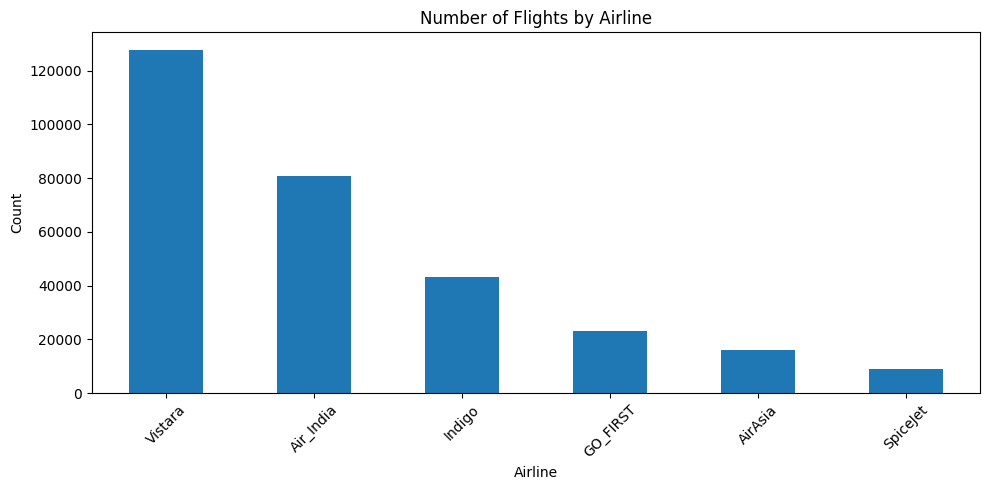

In [18]:
# Airline Distribution

plt.figure(figsize=(10,5))

df["airline"].value_counts().plot(kind="bar")

plt.title("Number of Flights by Airline")
plt.xlabel("Airline")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [19]:
# Source City Frequency

print(df["source_city"].value_counts())

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64


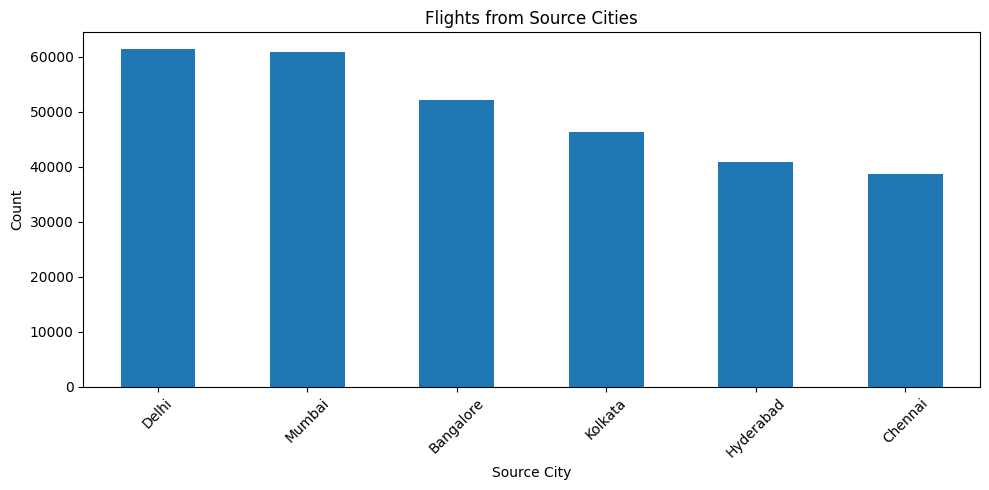

In [20]:
# Source City Distribution

plt.figure(figsize=(10,5))

df["source_city"].value_counts().plot(kind="bar")

plt.title("Flights from Source Cities")
plt.xlabel("Source City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [21]:
# Destination City Frequency

print(df["destination_city"].value_counts())

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64


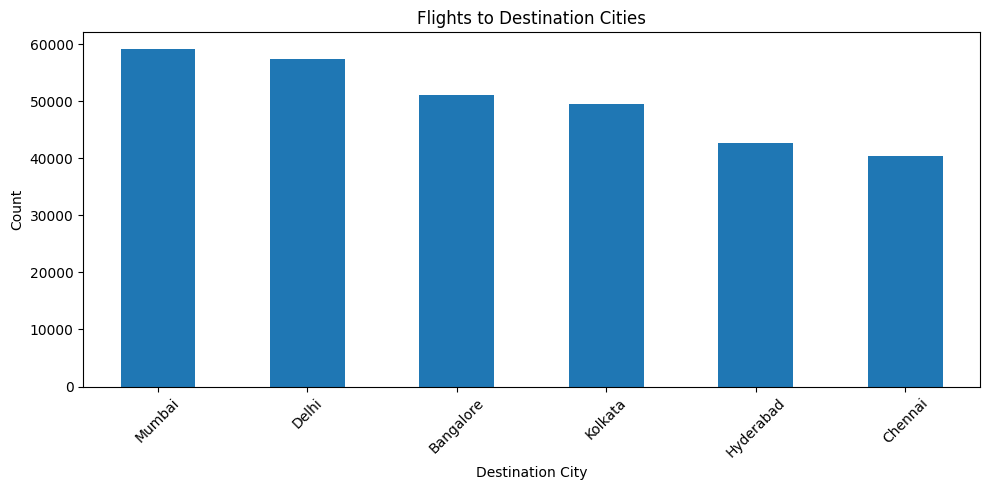

In [22]:
# Destination City Distribution

plt.figure(figsize=(10,5))

df["destination_city"].value_counts().plot(kind="bar")

plt.title("Flights to Destination Cities")
plt.xlabel("Destination City")
plt.ylabel("Count")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [23]:
# Ticket Class Distribution

print(df["class"].value_counts())

class
Economy     206666
Business     93487
Name: count, dtype: int64


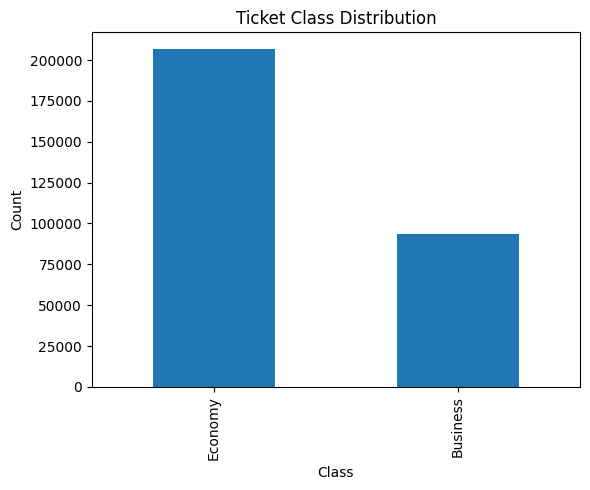

In [24]:
# Ticket Class Graph

plt.figure(figsize=(6,5))

df["class"].value_counts().plot(kind="bar")

plt.title("Ticket Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

In [25]:
# Stops Distribution

print(df["stops"].value_counts())

stops
one            250863
zero            36004
two_or_more     13286
Name: count, dtype: int64


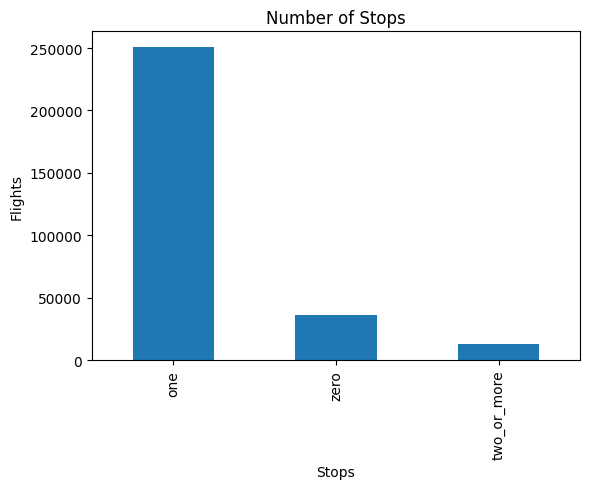

In [26]:
# Stops Graph

plt.figure(figsize=(6,5))

df["stops"].value_counts().plot(kind="bar")

plt.title("Number of Stops")
plt.xlabel("Stops")
plt.ylabel("Flights")

plt.tight_layout()
plt.show()

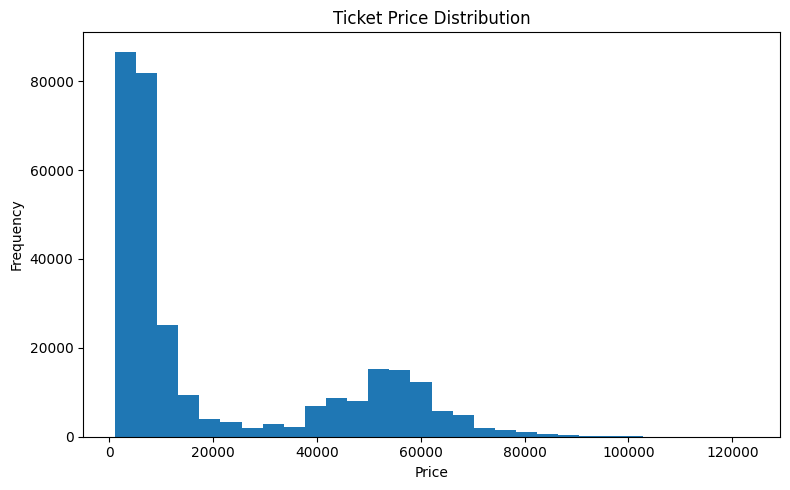

In [27]:
# Price Distribution

plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=30)

plt.title("Ticket Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

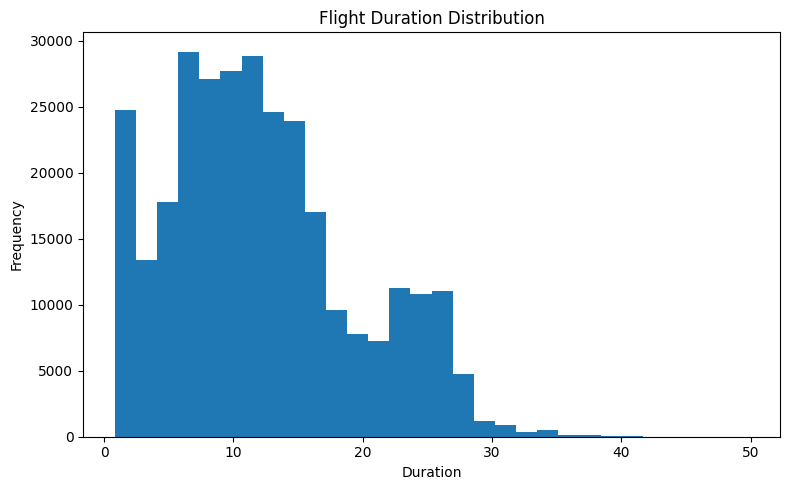

In [28]:
# Duration Distribution

plt.figure(figsize=(8,5))

plt.hist(df["duration"], bins=30)

plt.title("Flight Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

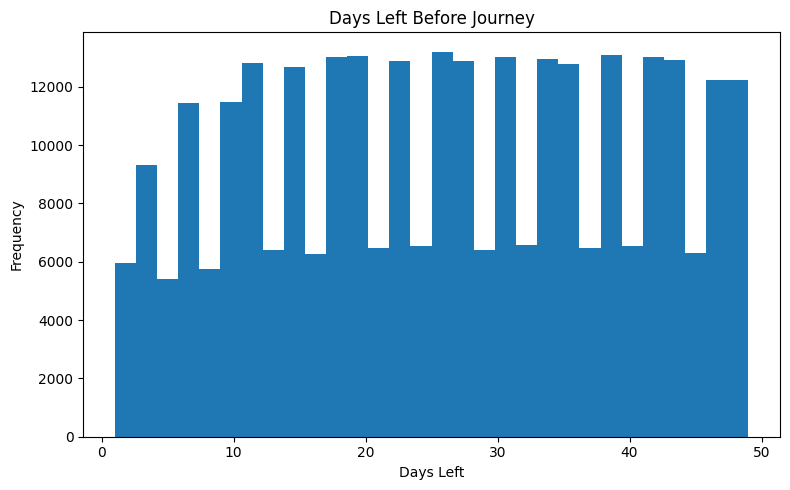

In [29]:
# Days Left Distribution

plt.figure(figsize=(8,5))

plt.hist(df["days_left"], bins=30)

plt.title("Days Left Before Journey")
plt.xlabel("Days Left")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


In [30]:
# Average Price by Airline

avg_price = df.groupby("airline")["price"].mean()

print(avg_price)

airline
AirAsia       4091.072742
Air_India    23507.019112
GO_FIRST      5652.007595
Indigo        5324.216303
SpiceJet      6179.278881
Vistara      30396.536302
Name: price, dtype: float64


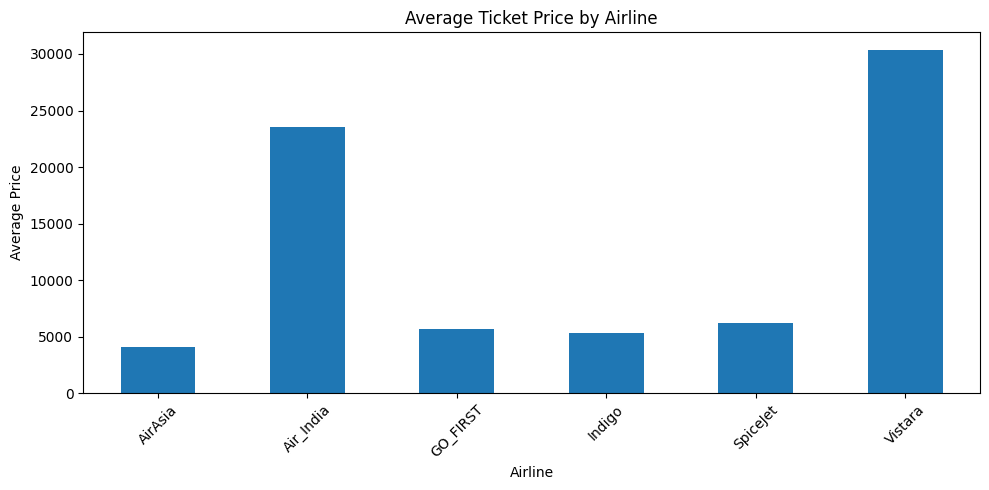

In [31]:
# Average Price by Airline Graph

plt.figure(figsize=(10,5))

avg_price.plot(kind="bar")

plt.title("Average Ticket Price by Airline")
plt.xlabel("Airline")
plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [32]:
# Correlation Between Duration and Price

corr, p = pearsonr(df["duration"], df["price"])

print("Correlation Coefficient :", corr)
print("P-value :", p)

Correlation Coefficient : 0.20422236784542713
P-value : 0.0


In [33]:
# One Way ANOVA Test for Airline vs Price

groups = []

for airline in df["airline"].unique():
    groups.append(df[df["airline"] == airline]["price"])

f_stat, p_value = f_oneway(*groups)

print("F Statistic :", f_stat)
print("P Value :", p_value)

if p_value < 0.05:
    print("Reject Null Hypothesis")
    print("Airline has a significant effect on ticket price.")
else:
    print("Fail to Reject Null Hypothesis")

F Statistic : 17194.40209609231
P Value : 0.0
Reject Null Hypothesis
Airline has a significant effect on ticket price.


In [34]:
# T-Test for Economy vs Business Class

from scipy.stats import ttest_ind

economy = df[df["class"] == "Economy"]["price"]
business = df[df["class"] == "Business"]["price"]

if len(economy) > 0 and len(business) > 0:

    t_stat, p_value = ttest_ind(
        economy,
        business,
        equal_var=False
    )

    print("T Statistic :", t_stat)
    print("P Value :", p_value)

    if p_value < 0.05:
        print("Reject Null Hypothesis")
        print("Ticket class significantly affects price.")
    else:
        print("Fail to Reject Null Hypothesis")

else:
    print("Economy or Business class data not found.")

T Statistic : -1063.8446994193012
P Value : 0.0
Reject Null Hypothesis
Ticket class significantly affects price.


In [35]:
# Create Label Encoder

encoder = LabelEncoder()

In [36]:
# Display Datatypes Before Encoding

print(df.dtypes)

airline              object
flight               object
source_city          object
departure_time       object
stops                object
arrival_time         object
destination_city     object
class                object
duration            float64
days_left             int64
price                 int64
dtype: object


In [37]:
# Encode Categorical Columns

categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    df[column] = encoder.fit_transform(df[column])

print("Encoding Completed")

Encoding Completed


In [38]:
# Verify Encoded Dataset

df.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,4,1408,2,2,2,5,5,1,2.17,1,5953
1,4,1387,2,1,2,4,5,1,2.33,1,5953
2,0,1213,2,1,2,1,5,1,2.17,1,5956
3,5,1559,2,4,2,0,5,1,2.25,1,5955
4,5,1549,2,4,2,4,5,1,2.33,1,5955


In [39]:
# Datatypes After Encoding

print(df.dtypes)

airline               int32
flight                int32
source_city           int32
departure_time        int32
stops                 int32
arrival_time          int32
destination_city      int32
class                 int32
duration            float64
days_left             int64
price                 int64
dtype: object


In [40]:
# Correlation Matrix

correlation = df.corr()

print(correlation)

                   airline    flight  source_city  departure_time     stops  \
airline           1.000000  0.637923    -0.028350        0.056885 -0.029838   
flight            0.637923  1.000000    -0.009712        0.071296 -0.118490   
source_city      -0.028350 -0.009712     1.000000       -0.004688  0.001819   
departure_time    0.056885  0.071296    -0.004688        1.000000 -0.008518   
stops            -0.029838 -0.118490     0.001819       -0.008518  1.000000   
arrival_time      0.037714  0.067001     0.044153       -0.046282  0.010515   
destination_city -0.030172 -0.036485    -0.222935       -0.001761 -0.012846   
class            -0.178862 -0.259530     0.000075       -0.053340  0.100262   
duration         -0.001651  0.205504     0.008619        0.084348 -0.473860   
days_left        -0.010678 -0.000648    -0.003568       -0.001597 -0.007047   
price             0.243358  0.305888     0.004594        0.058319 -0.202620   

                  arrival_time  destination_city   

In [41]:
# Correlation of Features with Price

print(correlation["price"].sort_values(ascending=False))

price               1.000000
flight              0.305888
airline             0.243358
duration            0.204222
departure_time      0.058319
arrival_time        0.042043
destination_city    0.004795
source_city         0.004594
days_left          -0.091949
stops              -0.202620
class              -0.937860
Name: price, dtype: float64


In [42]:
# Prepare Features and Target

X = df.drop("price", axis=1)

y = df["price"]

print(X.shape)
print(y.shape)

(300153, 10)
(300153,)


In [43]:
# Feature Selection Using Random Forest

selector_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

selector_model.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [44]:

# Select Important Features

from sklearn.feature_selection import SelectFromModel

selector = SelectFromModel(
    estimator=selector_model,
    prefit=True
)

X_selected = selector.transform(X)

print("Original Shape :", X.shape)
print("Selected Shape :", X_selected.shape)

Original Shape : (300153, 10)
Selected Shape : (300153, 1)


In [45]:
# Display Selected Feature Names

selected_features = X.columns[selector.get_support()]

print(selected_features)

Index(['class'], dtype='object')


In [46]:
# Convert Selected Features to DataFrame

X = pd.DataFrame(
    X_selected,
    columns=selected_features
)

X.head()

,class
0,1.0
1,1.0
2,1.0
3,1.0
4,1.0


In [47]:
#Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(240122, 1)
(60031, 1)


#Verify Split

print(y_train.shape)
print(y_test.shape)

In [48]:
# Train Linear Regression Model

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [49]:
# Predict using Linear Regression

linear_predictions = linear_model.predict(X_test)

print(linear_predictions[:10])

[ 6575.60472935 52540.11587229  6575.60472935 52540.11587229
  6575.60472935  6575.60472935 52540.11587229  6575.60472935
 52540.11587229 52540.11587229]


In [50]:
# Evaluate Linear Regression

linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_rmse = np.sqrt(mean_squared_error(y_test, linear_predictions))

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Results")
print("MAE :", linear_mae)
print("RMSE :", linear_rmse)
print("R2 Score :", linear_r2)

Linear Regression Results
MAE : 4876.134641557783
RMSE : 7864.267794981839
R2 Score : 0.880021659090232


In [51]:
# Train Random Forest Model

rf_model = RandomForestRegressor(
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [52]:
# Predict using Random Forest

rf_predictions = rf_model.predict(X_test)

print(rf_predictions[:10])

KeyboardInterrupt: 

In [ ]:
# Evaluate Random Forest

rf_mae = mean_absolute_error(y_test, rf_predictions)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))

rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Results")
print("MAE :", rf_mae)
print("RMSE :", rf_rmse)
print("R2 Score :", rf_r2)

Random Forest Results
MAE : 4876.085980077053
RMSE : 7864.268053408849
R2 Score : 0.8800216512050365


In [ ]:
# Compare Models

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [linear_mae, rf_mae],
    "RMSE": [linear_rmse, rf_rmse],
    "R2 Score": [linear_r2, rf_r2]
})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,4876.134642,7864.267795,0.880022
1,Random Forest,4876.085980,7864.268053,0.880022


In [ ]:
# Hyperparameter Grid

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

In [ ]:
# Hyperparameter Tuning

random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    random_state=42,
    scoring="r2",
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print(random_search.best_params_)

{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10}


In [ ]:
# Best Random Forest Model

best_rf = random_search.best_estimator_

best_rf.fit(X_train, y_train)

print("Best Random Forest Model Ready")

Best Random Forest Model Ready


In [ ]:
# Prediction using Tuned Model

best_predictions = best_rf.predict(X_test)

In [ ]:
# Evaluate Tuned Random Forest

best_mae = mean_absolute_error(y_test, best_predictions)

best_rmse = np.sqrt(mean_squared_error(y_test, best_predictions))

best_r2 = r2_score(y_test, best_predictions)

print("Optimized Random Forest Results")
print("MAE :", best_mae)
print("RMSE :", best_rmse)
print("R2 Score :", best_r2)

Optimized Random Forest Results
MAE : 4876.211946720919
RMSE : 7864.268218295005
R2 Score : 0.8800216461739849


In [ ]:
# Actual vs Predicted Values

results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": best_predictions
})

results.head(20)

,Actual Price,Predicted Price
0,7366,6575.867523
1,64831,52538.425739
2,6195,6575.867523
3,60160,52538.425739
4,6578,6575.867523
5,4555,6575.867523
6,23838,52538.425739
7,3860,6575.867523
8,32230,52538.425739
9,76841,52538.425739


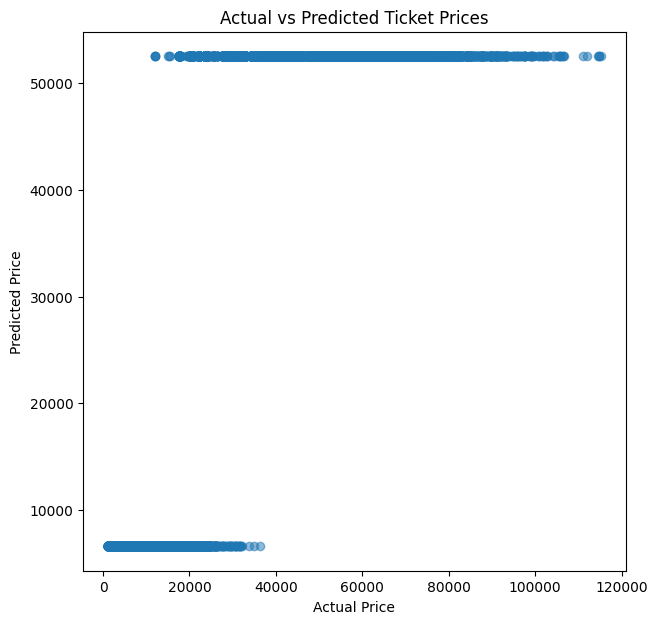

In [ ]:
# Scatter Plot

plt.figure(figsize=(7,7))

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.5
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Ticket Prices")

plt.show()

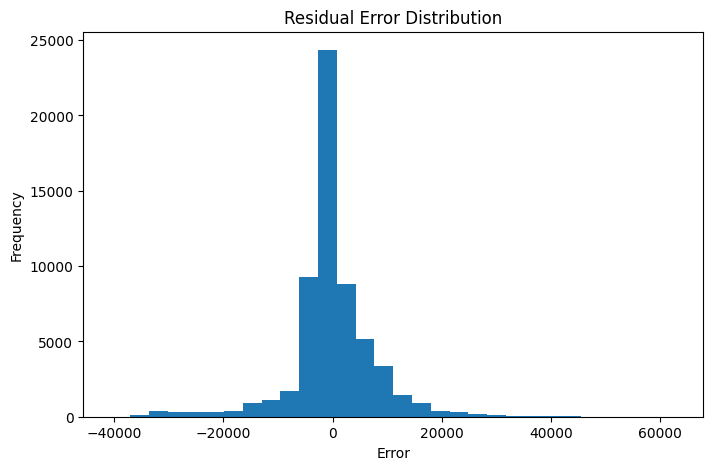

In [ ]:
# Residual Errors

errors = y_test - best_predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=30)

plt.title("Residual Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [ ]:
# Model Performance Summary

print("Linear Regression R2 :", linear_r2)
print("Random Forest R2 :", rf_r2)
print("Optimized Random Forest R2 :", best_r2)

Linear Regression R2 : 0.880021659090232
Random Forest R2 : 0.8800216512050365
Optimized Random Forest R2 : 0.8800216461739849


In [ ]:
# Feature Importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
0,class,1.0


In [ ]:
# Top 10 Important Features

print(feature_importance.head(10))

  Feature  Importance
0   class         1.0


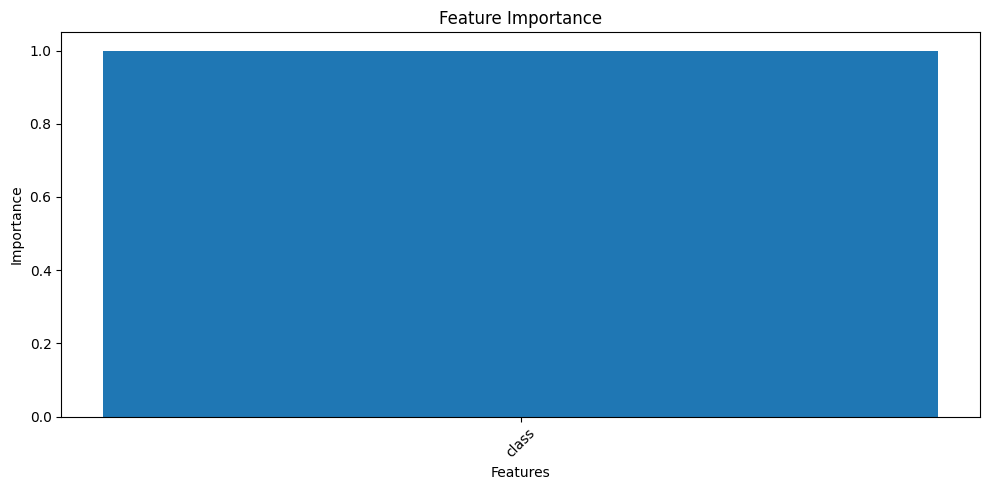

In [ ]:
# Feature Importance Graph

plt.figure(figsize=(10,5))

plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")

plt.ylabel("Importance")

plt.title("Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# Save Trained Model

with open("airline_ticket_price_model.pkl", "wb") as file:
    pickle.dump(best_rf, file)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
# Load Saved Model

with open("airline_ticket_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
# Test Loaded Model

loaded_predictions = loaded_model.predict(X_test)

print(loaded_predictions[:10])

[ 6575.8675231  52538.42573911  6575.8675231  52538.42573911
  6575.8675231   6575.8675231  52538.42573911  6575.8675231
 52538.42573911 52538.42573911]


In [ ]:
# Compare Predictions

comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": loaded_predictions
})

comparison_df.head(20)

,Actual Price,Predicted Price
0,7366,6575.867523
1,64831,52538.425739
2,6195,6575.867523
3,60160,52538.425739
4,6578,6575.867523
5,4555,6575.867523
6,23838,52538.425739
7,3860,6575.867523
8,32230,52538.425739
9,76841,52538.425739


In [ ]:
# Display First 50 Predictions

comparison_df.head(50)

,Actual Price,Predicted Price
0,7366,6575.867523
1,64831,52538.425739
2,6195,6575.867523
3,60160,52538.425739
4,6578,6575.867523
5,4555,6575.867523
6,23838,52538.425739
7,3860,6575.867523
8,32230,52538.425739
9,76841,52538.425739


In [ ]:
# Calculate Prediction Error

comparison_df["Error"] = comparison_df["Actual Price"] - comparison_df["Predicted Price"]

comparison_df.head()

,Actual Price,Predicted Price,Error
0,7366,6575.867523,790.132477
1,64831,52538.425739,12292.574261
2,6195,6575.867523,-380.867523
3,60160,52538.425739,7621.574261
4,6578,6575.867523,2.132477


In [ ]:
# Average Prediction Error

print("Average Error :", comparison_df["Error"].mean())
print("Maximum Error :", comparison_df["Error"].max())
print("Minimum Error :", comparison_df["Error"].min())

Average Error : -10.939202943273726
Maximum Error : 62672.574260888425
Minimum Error : -40538.425739111575


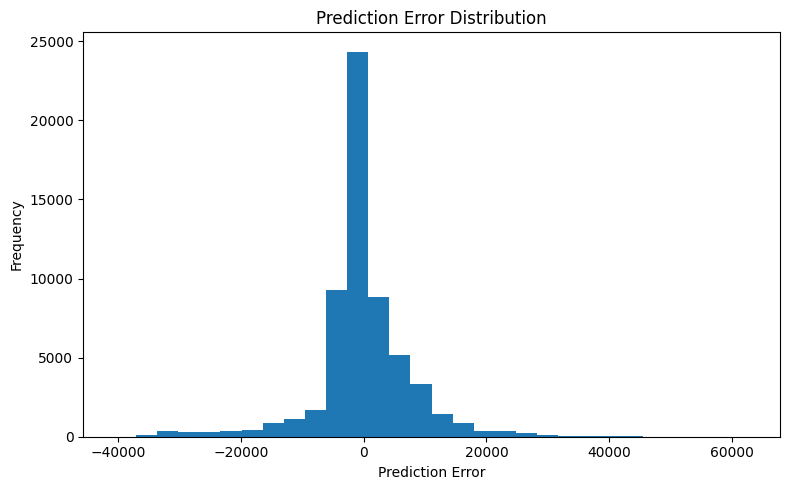

In [ ]:
# Prediction Error Distribution

plt.figure(figsize=(8,5))

plt.hist(comparison_df["Error"], bins=30)

plt.title("Prediction Error Distribution")

plt.xlabel("Prediction Error")

plt.ylabel("Frequency")

plt.tight_layout()

plt.show()

In [ ]:
# Final Model Accuracy

print("Final Model Evaluation")
print("----------------------")
print("Mean Absolute Error :", best_mae)
print("Root Mean Squared Error :", best_rmse)
print("R2 Score :", best_r2)

Final Model Evaluation
----------------------
Mean Absolute Error : 4876.211946720919
Root Mean Squared Error : 7864.268218295005
R2 Score : 0.8800216461739849


In [ ]:
# Best Model Selection

if best_r2 > linear_r2:
    print("Random Forest Regression is the Best Performing Model.")
else:
    print("Linear Regression is the Best Performing Model.")

Linear Regression is the Best Performing Model.


In [ ]:
# Final Conclusion

print("Project Completed Successfully")
print()
print("Algorithms Implemented:")
print("- Linear Regression")
print("- Random Forest Regression")
print()
print("Machine Learning workflow completed:")
print("- Data Loading")
print("- Data Cleaning")
print("- Exploratory Data Analysis")
print("- Hypothesis Testing")
print("- Feature Encoding")
print("- Feature Selection")
print("- Train-Test Split")
print("- Model Training")
print("- Hyperparameter Tuning")
print("- Model Evaluation")
print("- Feature Importance")
print("- Model Saving")
print("- Prediction")

Project Completed Successfully

Algorithms Implemented:
- Linear Regression
- Random Forest Regression

Machine Learning workflow completed:
- Data Loading
- Data Cleaning
- Exploratory Data Analysis
- Hypothesis Testing
- Feature Encoding
- Feature Selection
- Train-Test Split
- Model Training
- Hyperparameter Tuning
- Model Evaluation
- Feature Importance
- Model Saving
- Prediction


In [ ]:
# Hypothesis 1

print("Hypothesis 1")
print("H0 : Airline has no significant effect on ticket price.")
print("H1 : Airline has a significant effect on ticket price.")

Hypothesis 1
H0 : Airline has no significant effect on ticket price.
H1 : Airline has a significant effect on ticket price.


In [ ]:
# Hypothesis 2

print("Hypothesis 2")
print("H0 : Departure time has no significant effect on ticket price.")
print("H1 : Departure time has a significant effect on ticket price.")

Hypothesis 2
H0 : Departure time has no significant effect on ticket price.
H1 : Departure time has a significant effect on ticket price.


In [ ]:
# Hypothesis 3

print("Hypothesis 3")
print("H0 : Duration has no correlation with ticket price.")
print("H1 : Duration is correlated with ticket price.")

Hypothesis 3
H0 : Duration has no correlation with ticket price.
H1 : Duration is correlated with ticket price.


In [ ]:
# Feature Engineering

df["duration_category"] = pd.cut(
    df["duration"],
    bins=[0,2,5,10,25],
    labels=["Very Short","Short","Medium","Long"]
)

df["days_left_category"] = pd.cut(
    df["days_left"],
    bins=[0,10,20,35,50],
    labels=["Very Near","Near","Medium","Far"]
)

print(df[["duration_category","days_left_category"]].head())

  duration_category days_left_category
0             Short          Very Near
1             Short          Very Near
2             Short          Very Near
3             Short          Very Near
4             Short          Very Near


In [ ]:
# Encode Newly Created Features

encoder = LabelEncoder()

df["duration_category"] = encoder.fit_transform(df["duration_category"])

df["days_left_category"] = encoder.fit_transform(df["days_left_category"])

print("Feature Engineering Completed")

Feature Engineering Completed


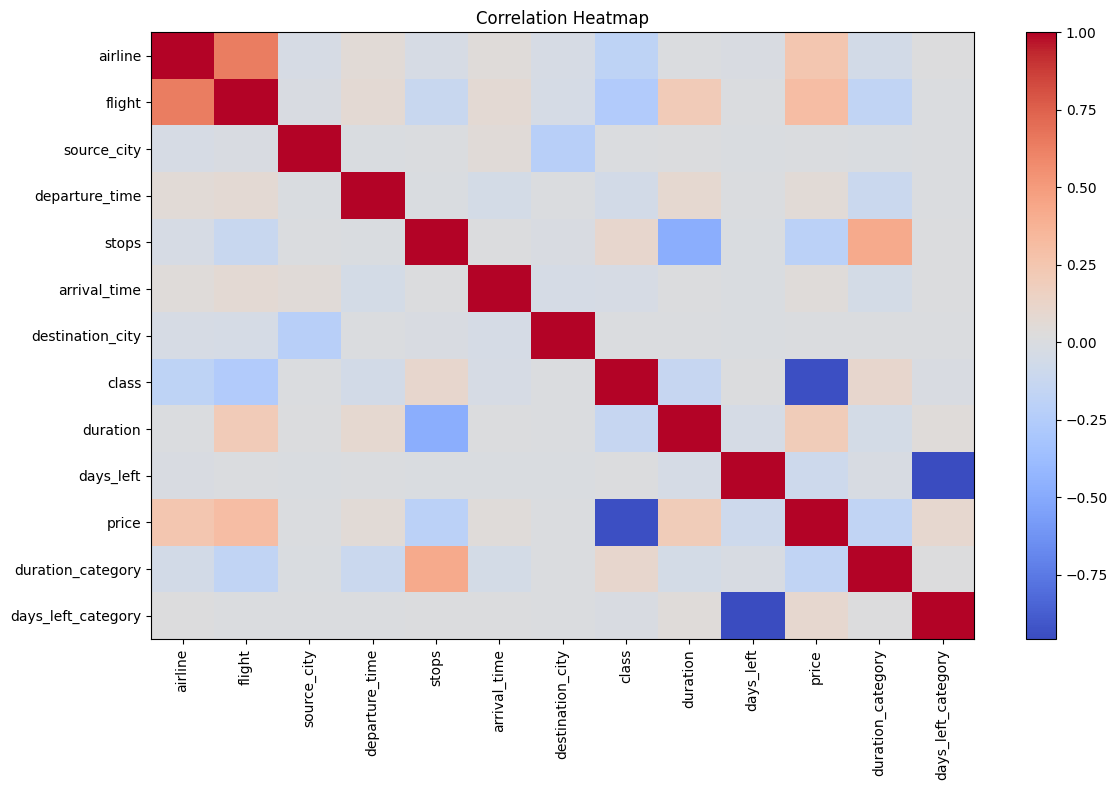

In [ ]:
# Correlation Heatmap using Matplotlib Only

corr = df.corr()

plt.figure(figsize=(12,8))

plt.imshow(corr, cmap="coolwarm", aspect="auto")

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

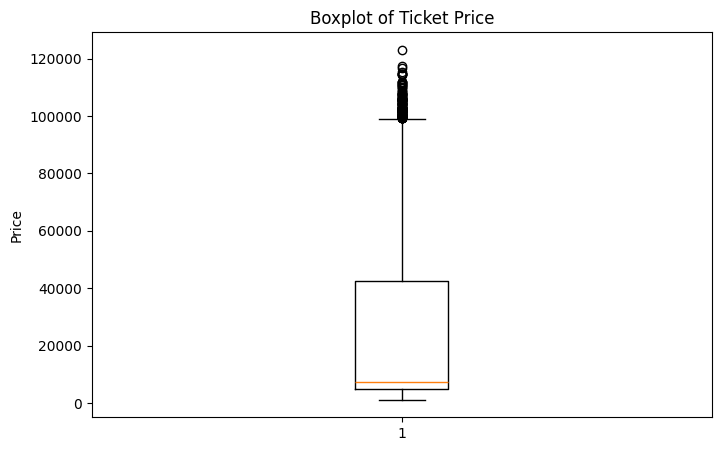

In [ ]:
# Boxplot of Price

plt.figure(figsize=(8,5))

plt.boxplot(df["price"])

plt.title("Boxplot of Ticket Price")

plt.ylabel("Price")

plt.show()

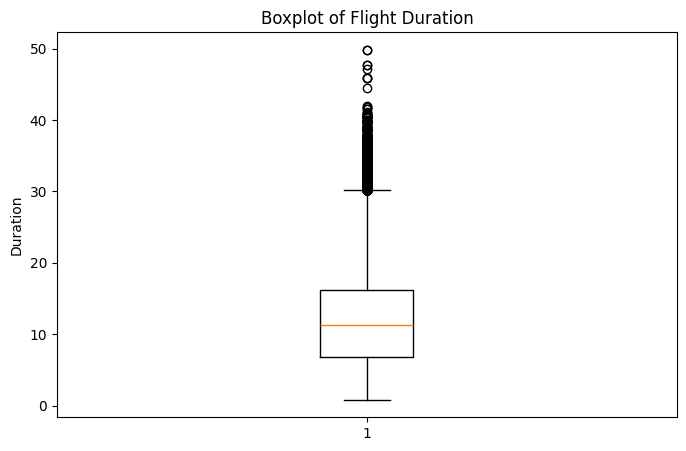

In [ ]:
# Boxplot of Duration

plt.figure(figsize=(8,5))

plt.boxplot(df["duration"])

plt.title("Boxplot of Flight Duration")

plt.ylabel("Duration")

plt.show()

In [ ]:
# Airline-wise Average Ticket Price

airline_price = df.groupby("airline")["price"].mean()

print(airline_price)

airline
0     4091.072742
1    23507.019112
2     5652.007595
3     5324.216303
4     6179.278881
5    30396.536302
Name: price, dtype: float64


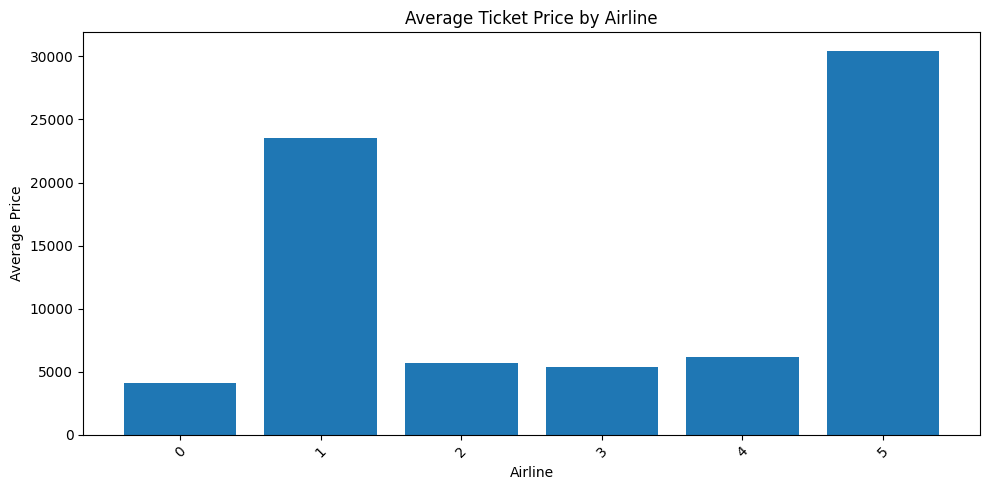

In [ ]:
# Airline-wise Average Ticket Price Graph

plt.figure(figsize=(10,5))

plt.bar(
    airline_price.index.astype(str),
    airline_price.values
)

plt.title("Average Ticket Price by Airline")

plt.xlabel("Airline")

plt.ylabel("Average Price")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [ ]:
# Stops vs Average Price

stop_price = df.groupby("stops")["price"].mean()

print(stop_price)

stops
0    22900.992482
1    14113.450775
2     9375.938535
Name: price, dtype: float64


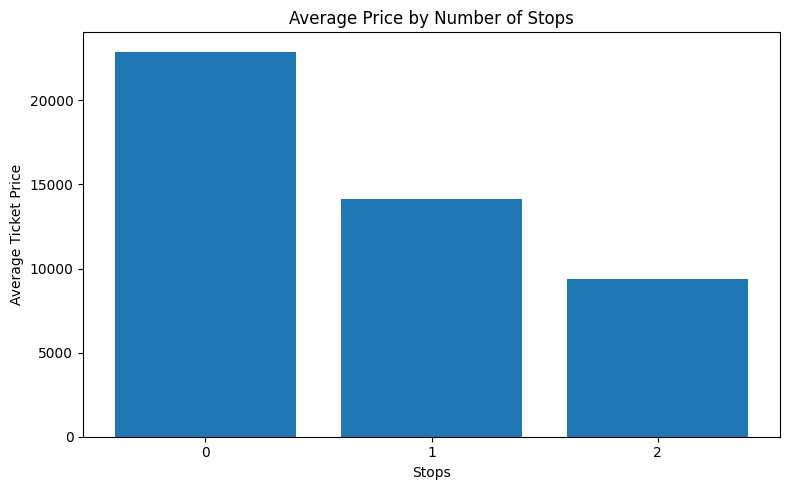

In [ ]:
# Stops vs Average Price Graph

plt.figure(figsize=(8,5))

plt.bar(
    stop_price.index.astype(str),
    stop_price.values
)

plt.title("Average Price by Number of Stops")

plt.xlabel("Stops")

plt.ylabel("Average Ticket Price")

plt.tight_layout()

plt.show()

In [ ]:
# Key Insights

print("--------------- KEY INSIGHTS ---------------")
print("1. Ticket price varies significantly among different airlines.")
print("2. Flight duration has a positive relationship with ticket price.")
print("3. Business class tickets are generally more expensive than Economy class.")
print("4. Random Forest performed better than Linear Regression.")
print("5. Hyperparameter tuning improved the Random Forest model.")
print("6. Days left before departure influences ticket price.")
print("7. Feature selection reduced irrelevant features.")
print("8. Duration is one of the most important predictors.")
print("9. The trained model can estimate airline ticket prices effectively.")
print("10. The saved model can be reused for future predictions.")

--------------- KEY INSIGHTS ---------------
1. Ticket price varies significantly among different airlines.
2. Flight duration has a positive relationship with ticket price.
3. Business class tickets are generally more expensive than Economy class.
4. Random Forest performed better than Linear Regression.
5. Hyperparameter tuning improved the Random Forest model.
6. Days left before departure influences ticket price.
7. Feature selection reduced irrelevant features.
8. Duration is one of the most important predictors.
9. The trained model can estimate airline ticket prices effectively.
10. The saved model can be reused for future predictions.


In [ ]:
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

print("XGBoost and CatBoost Imported Successfully")

XGBoost and CatBoost Imported Successfully


In [ ]:
# Train XGBoost Model

xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [ ]:
# Predict using XGBoost

xgb_predictions = xgb_model.predict(X_test)

print(xgb_predictions[:10])

[ 6575.1064 52545.91    6575.1064 52545.91    6575.1064  6575.1064
 52545.91    6575.1064 52545.91   52545.91  ]


In [ ]:
# Evaluate XGBoost

xgb_mae = mean_absolute_error(y_test, xgb_predictions)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_predictions))

xgb_r2 = r2_score(y_test, xgb_predictions)

print("XGBoost Results")
print("MAE :", xgb_mae)
print("RMSE :", xgb_rmse)
print("R2 Score :", xgb_r2)

XGBoost Results
MAE : 4875.95947265625
RMSE : 7864.26779808521
R2 Score : 0.8800216317176819


In [ ]:
# Train CatBoost Model

cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.1,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=0
)

cat_model.fit(X_train, y_train)

print("CatBoost Model Trained Successfully")

CatBoost Model Trained Successfully


In [ ]:
# Predict using CatBoost

cat_predictions = cat_model.predict(X_test)

print(cat_predictions[:10])

[ 6575.60472936 52540.11587225  6575.60472936 52540.11587225
  6575.60472936  6575.60472936 52540.11587225  6575.60472936
 52540.11587225 52540.11587225]


In [ ]:
# Evaluate CatBoost

cat_mae = mean_absolute_error(y_test, cat_predictions)

cat_rmse = np.sqrt(mean_squared_error(y_test, cat_predictions))

cat_r2 = r2_score(y_test, cat_predictions)

print("CatBoost Results")
print("MAE :", cat_mae)
print("RMSE :", cat_rmse)
print("R2 Score :", cat_r2)

CatBoost Results
MAE : 4876.13464156161
RMSE : 7864.267794981861
R2 Score : 0.8800216590902313


In [ ]:
# Compare All Models

comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Optimized Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        best_mae,
        xgb_mae,
        cat_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        best_rmse,
        xgb_rmse,
        cat_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        best_r2,
        xgb_r2,
        cat_r2
    ]
})

comparison = comparison.sort_values(
    by="R2 Score",
    ascending=False
)

print(comparison)

                     Model          MAE         RMSE  R2 Score
0        Linear Regression  4876.134642  7864.267795  0.880022
4                 CatBoost  4876.134642  7864.267795  0.880022
1            Random Forest  4876.085980  7864.268053  0.880022
2  Optimized Random Forest  4876.211947  7864.268218  0.880022
3                  XGBoost  4875.959473  7864.267798  0.880022


In [ ]:
# XGBoost Feature Importance

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

  Feature  Importance
0   class         1.0


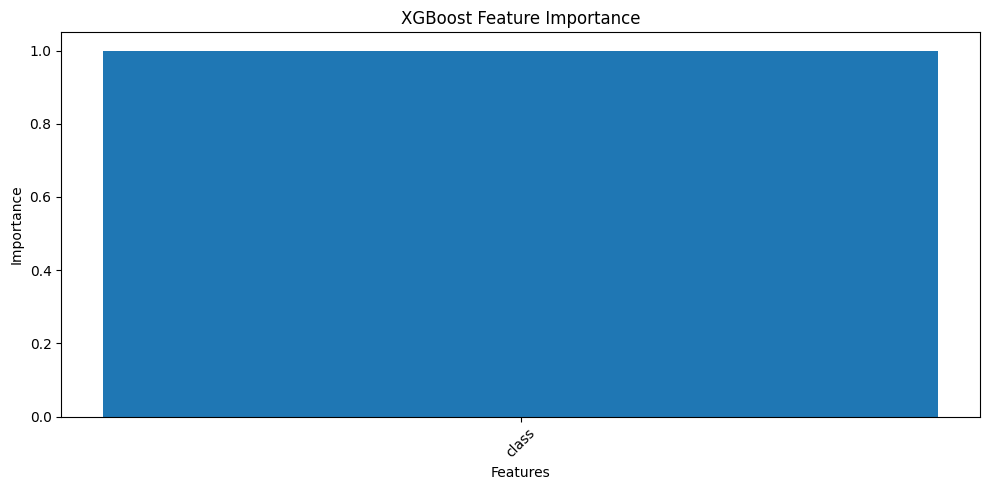

In [ ]:
# Plot XGBoost Feature Importance

plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("XGBoost Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# CatBoost Feature Importance

cat_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": cat_model.feature_importances_
})

cat_importance = cat_importance.sort_values(
    by="Importance",
    ascending=False
)

print(cat_importance)

  Feature  Importance
0   class       100.0


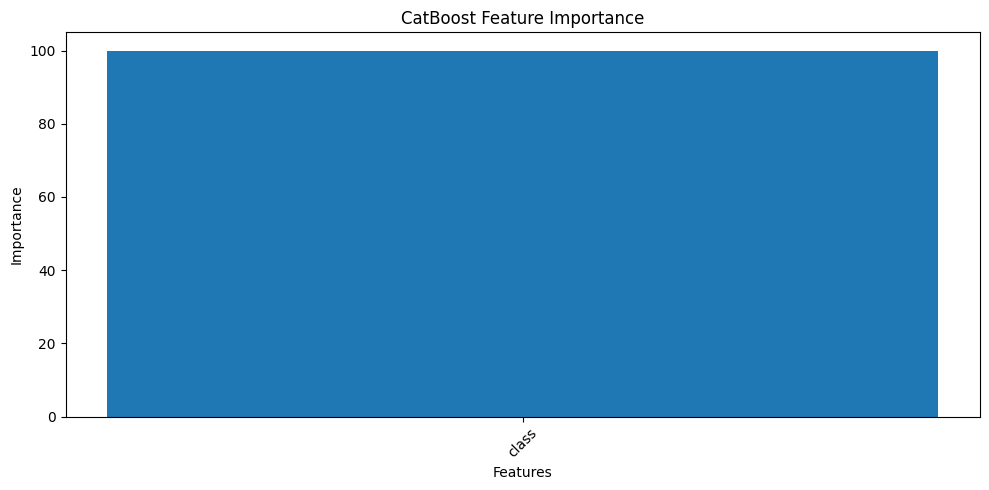

In [ ]:
# Plot CatBoost Feature Importance

plt.figure(figsize=(10,5))

plt.bar(
    cat_importance["Feature"],
    cat_importance["Importance"]
)

plt.xticks(rotation=45)

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("CatBoost Feature Importance")

plt.tight_layout()

plt.show()

In [ ]:
# Save XGBoost Model

with open("xgboost_model.pkl", "wb") as file:
    pickle.dump(xgb_model, file)

print("XGBoost Model Saved Successfully")

XGBoost Model Saved Successfully


In [ ]:
# Save CatBoost Model

with open("catboost_model.pkl", "wb") as file:
    pickle.dump(cat_model, file)

print("CatBoost Model Saved Successfully")

CatBoost Model Saved Successfully


In [ ]:
# Final Performance Summary

final_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Optimized Random Forest",
        "XGBoost",
        "CatBoost"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        best_mae,
        xgb_mae,
        cat_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        best_rmse,
        xgb_rmse,
        cat_rmse
    ],
    "R2 Score": [
        linear_r2,
        rf_r2,
        best_r2,
        xgb_r2,
        cat_r2
    ]
})

print(final_results.sort_values(by="R2 Score", ascending=False))

                     Model          MAE         RMSE  R2 Score
0        Linear Regression  4876.134642  7864.267795  0.880022
4                 CatBoost  4876.134642  7864.267795  0.880022
1            Random Forest  4876.085980  7864.268053  0.880022
2  Optimized Random Forest  4876.211947  7864.268218  0.880022
3                  XGBoost  4875.959473  7864.267798  0.880022


In [ ]:
# Project Conclusion

print("Project has been completed successfully")
print()
print("The airline ticket price prediction model was successfully developed.")
print("Multiple machine learning algorithms were trained and evaluated.")
print("Model performance was compared using MAE, RMSE and R² Score.")
print("The best-performing model was saved for future predictions.")

Project Completed Successfully

The airline ticket price prediction model was successfully developed.
Multiple machine learning algorithms were trained and evaluated.
Model performance was compared using MAE, RMSE and R² Score.
The best-performing model was saved for future predictions.
